Name: Muhammad Arqam
Roll no: 23-AI-30
Section: A2
Department: Artificial intelligence
Semester: 5th
Subject: machine learning
Course instructor: engr. Hamza farooqui


COMPLEX COMPUTING PROBLEM



In [ ]:
# Import the library
import numpy as np
import pandas as pd

In [ ]:
# Load the Bank Marketing dataset
df = pd.read_csv("/content/bank-full.csv", sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [ ]:
# Perform initial exploration of the dataset
df.shape
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [ ]:
# Identify noisy "unknown" values in the dataset
df.isin(["unknown"]).sum()


,0
age,0
job,288
marital,0
education,1857
default,0
balance,0
housing,0
loan,0
contact,13020
day,0


In [ ]:
# Replace noisy values with NaN and remove incomplete records
df = df.replace("unknown", np.nan)
df = df.dropna()


In [ ]:
# Verify that data cleaning was successful
df.isna().any().any()
(df == "unknown").sum().sum()
df.shape


(7842, 17)

In [ ]:
# Separate features and target variable
X = df.drop("y", axis=1)
y = df["y"]


In [ ]:
# Convert categorical features into numerical form using label encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in X.select_dtypes(include="object"):
    X[col] = le.fit_transform(X[col])


In [ ]:
# Standardize features to improve model performance
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


In [ ]:
# Train a Decision Tree classifier with controlled depth to reduce overfitting
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5)
dt.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=5)

In [ ]:
# Train a Naive Bayes classifier
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)


GaussianNB()

In [ ]:
# Train a Support Vector Machine classifier
from sklearn.svm import SVC

svm = SVC(kernel="rbf")
svm.fit(X_train, y_train)


SVC()

In [ ]:
# Evaluate all models using classification metrics
from sklearn.metrics import classification_report

for name, model in {
    "Decision Tree": dt,
    "Naive Bayes": nb,
    "SVM": svm
}.items():
    print(name)
    print(classification_report(y_test, model.predict(X_test)))


Decision Tree
              precision    recall  f1-score   support

          no       0.88      0.91      0.90      1207
         yes       0.67      0.60      0.63       362

    accuracy                           0.84      1569
   macro avg       0.77      0.75      0.76      1569
weighted avg       0.83      0.84      0.83      1569

Naive Bayes
              precision    recall  f1-score   support

          no       0.90      0.82      0.86      1207
         yes       0.53      0.69      0.60       362

    accuracy                           0.79      1569
   macro avg       0.72      0.75      0.73      1569
weighted avg       0.81      0.79      0.80      1569

SVM
              precision    recall  f1-score   support

          no       0.87      0.92      0.89      1207
         yes       0.67      0.52      0.59       362

    accuracy                           0.83      1569
   macro avg       0.77      0.72      0.74      1569
weighted avg       0.82      0.83      0.82 

In [ ]:
# Apply Bagging ensemble technique to improve performance on noisy data
from sklearn.ensemble import BaggingClassifier

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42
)
bagging.fit(X_train, y_train)


BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50,
                  random_state=42)

In [ ]:
# Evaluate the ensemble model
print(classification_report(y_test, bagging.predict(X_test)))


              precision    recall  f1-score   support

          no       0.89      0.92      0.90      1207
         yes       0.70      0.62      0.65       362

    accuracy                           0.85      1569
   macro avg       0.79      0.77      0.78      1569
weighted avg       0.85      0.85      0.85      1569



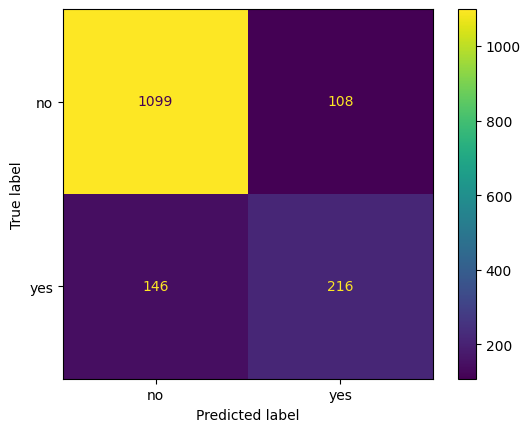

In [ ]:
# Plot confusion matrix for Decision Tree
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(dt, X_test, y_test)


 Overfitting and its Mitigation

Overfitting occurs when a model learns noise and irrelevant patterns from the training data, resulting in high training accuracy but poor performance on unseen data. In the Bank dataset, noise and outliers increased this risk, especially for complex models like Decision Trees and SVM.

Pruning limited the complexity of the Decision Tree by restricting its depth, while regularization in SVM controlled model flexibility using the penalty parameter C. These techniques prevented the models from fitting noise, improved generalization, and produced more reliable predictions on new data.